Github: https://github.com/magloev/magloevIND320
Streamlit app: https://magloevind320.streamlit.app/

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

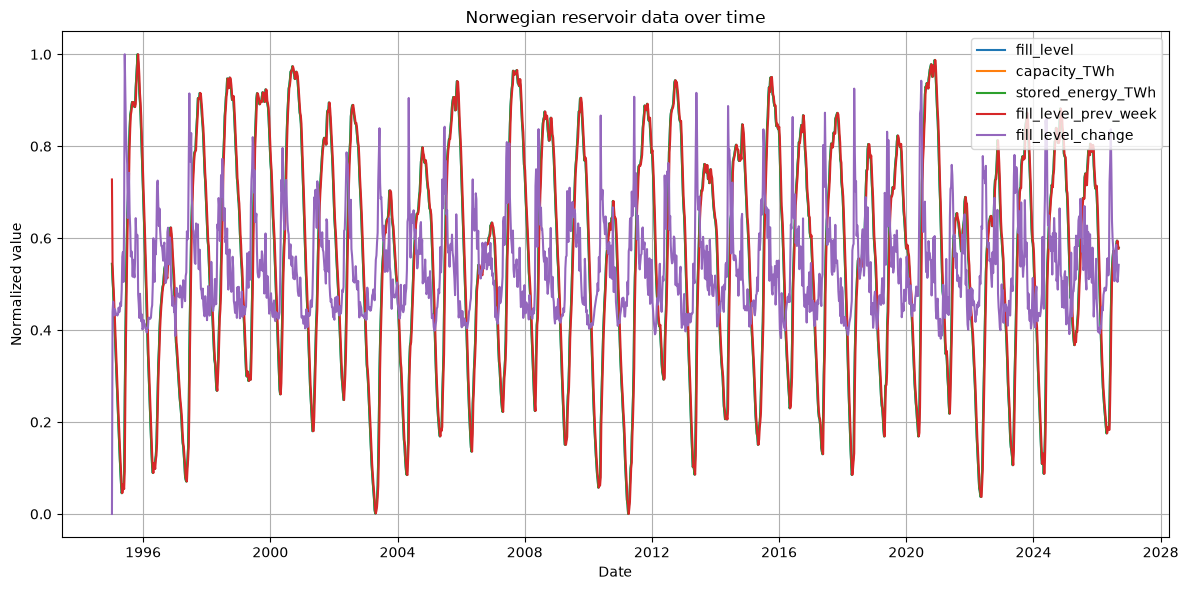

,date,area_type,area_id,iso_year,iso_week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_prev_week,fill_level_change
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
11380,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,0001-01-01T00:00:00,0.744693,-0.135837
14162,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,0001-01-01T00:00:00,0.798825,-0.162787
11198,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,0001-01-01T00:00:00,0.661432,-0.094525
8501,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
13262,1995-01-15,VASS,2,1995,2,0.588298,23.237715,13.670702,0001-01-01T00:00:00,0.608854,-0.020556


In [17]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('../data/reservoirs.csv')


df = df.rename(columns= {
    "dato_Id" : "date",
    "omrType" : "area_type",
    "omrnr"   : "area_id",
    "iso_aar" : "iso_year",
    "iso_uke"  : "iso_week",
    "fyllingsgrad" : "fill_level",
    "kapasitet_TWh" : "capacity_TWh",
    "fylling_TWh" : "stored_energy_TWh",
    "neste_Publiseringsdato" : "next_publication_date", 
    "fyllingsgrad_forrige_uke" : "fill_level_prev_week",
    "endring_fyllingsgrad" : "fill_level_change" })

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")
df.head()

columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "fill_level_prev_week",
    "fill_level_change"
]

df_no = df[
    (df["area_type"] == "NO") &
    (df["area_id"] == 0)
].copy()

df_no = df_no.sort_values("date")
df_no_normalized = df_no.copy()

for column in columns:
    df_no_normalized[column] = (
        (df_no[column] - df_no[column].min())
        / (df_no[column].max() - df_no[column].min())
    )

    plt.figure(figsize=(12, 6))

for column in columns:
    plt.plot(
        df_no_normalized["date"],
        df_no_normalized[column],
        label=column
    )

plt.title("Norwegian reservoir data over time")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

df.head(10)